In [9]:
# movie_stats_analysis.py
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
ratings = pd.read_csv("C:/Users/Ankit/anaconda_projects/ml-100k/u.data", sep="\t", names=["user_id", "item_id", "rating", "timestamp"])
movies = pd.read_csv(
    "C:/Users/Ankit/anaconda_projects/ml-100k/u.item",
    sep="|",
    encoding="latin-1",
    names=["item_id", "title", "release_date", "video_release_date", "IMDb_URL"] + [f"genre_{i}" for i in range(19)]
)

In [12]:
# Merge data
movie_data = pd.merge(ratings, movies[["item_id", "title"]], on="item_id")


In [14]:
# 1. Dataset Overview
print("\n--- Dataset Overview ---")
print("Total Users:", ratings['user_id'].nunique())
print("Total Movies:", ratings['item_id'].nunique())
print("Total Ratings:", len(ratings))
print("Average Rating:", round(ratings['rating'].mean(), 2))



--- Dataset Overview ---
Total Users: 943
Total Movies: 1682
Total Ratings: 100000
Average Rating: 3.53


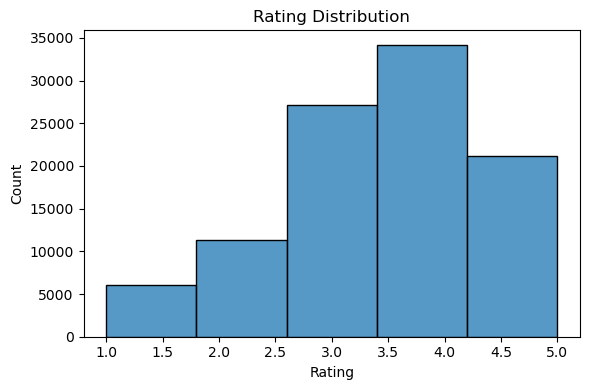

In [16]:
# 2. Rating Distribution
plt.figure(figsize=(6, 4))
sns.histplot(ratings['rating'], bins=5)
plt.title("Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig("rating_distribution.png")



--- Most Rated Movies ---
title
Star Wars (1977)                 583
Contact (1997)                   509
Fargo (1996)                     508
Return of the Jedi (1983)        507
Liar Liar (1997)                 485
English Patient, The (1996)      481
Scream (1996)                    478
Toy Story (1995)                 452
Air Force One (1997)             431
Independence Day (ID4) (1996)    429
Name: count, dtype: int64


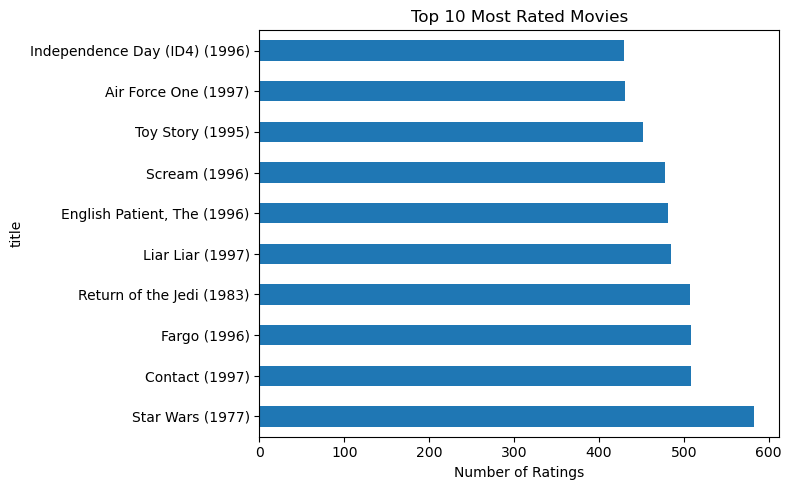

In [17]:
# 3. Most Rated Movies
most_rated = movie_data['title'].value_counts().head(10)
print("\n--- Most Rated Movies ---")
print(most_rated)
plt.figure(figsize=(8, 5))
most_rated.plot(kind='barh')
plt.xlabel("Number of Ratings")
plt.title("Top 10 Most Rated Movies")
plt.tight_layout()
plt.savefig("most_rated_movies.png")

In [18]:


# 4. Best Rated Movies (min 50 ratings)
movie_stats = movie_data.groupby('title').agg({'rating': ['mean', 'count']})
movie_stats.columns = ['avg_rating', 'rating_count']
best_movies = movie_stats[movie_stats['rating_count'] >= 50].sort_values('avg_rating', ascending=False).head(10)
print("\n--- Best Rated Movies (min 50 ratings) ---")
print(best_movies)


--- Best Rated Movies (min 50 ratings) ---
                                                    avg_rating  rating_count
title                                                                       
Close Shave, A (1995)                                 4.491071           112
Schindler's List (1993)                               4.466443           298
Wrong Trousers, The (1993)                            4.466102           118
Casablanca (1942)                                     4.456790           243
Wallace & Gromit: The Best of Aardman Animation...    4.447761            67
Shawshank Redemption, The (1994)                      4.445230           283
Rear Window (1954)                                    4.387560           209
Usual Suspects, The (1995)                            4.385768           267
Star Wars (1977)                                      4.358491           583
12 Angry Men (1957)                                   4.344000           125


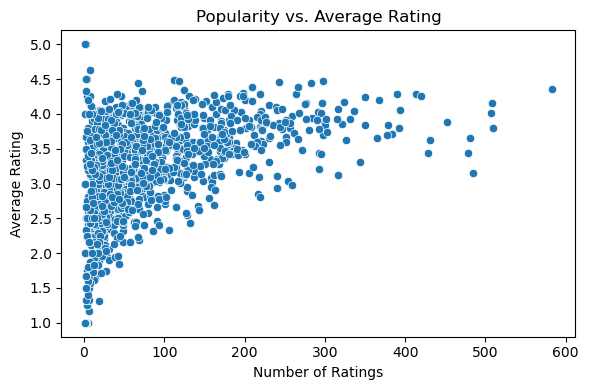

In [22]:
# 5. Correlation: Popularity vs Rating
plt.figure(figsize=(6, 4))
sns.scatterplot(data=movie_stats, x='rating_count', y='avg_rating')
plt.xlabel("Number of Ratings")
plt.ylabel("Average Rating")
plt.title("Popularity vs. Average Rating")
plt.tight_layout()
plt.savefig("correlation_rating_popularity.png")
